In [1]:
import os
os.environ['MEMORY_LIMIT'] = '16GB'
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import gridspec
from os.path import exists, join
from io import StringIO  
from datetime import timedelta
import math

ALGORITHMS = {
    'structural': 'Structural',
    'structural-variant': 'Splitted Structural',
    'sed': 'Sed',
    'lblint': 'Lbl-Int',
    'bib': 'Binary branch',
    'sedindex': 'Sed Index',
    'lblindex': 'Lbl-Int Index',
    'structuralindex': 'Structural Index',
}

datasets = ('dblp', 'ptb', 'python', 'sentiment', 'swissprot', 'treefam')
ALGORITHMS_ENUM_NAMES = {
    'structural': 'Structural',
    'structural-variant': 'StructuralVariant',
    'sed': 'Sed',
    'lblint': 'Lblint',
    'bib': 'Bib'
}

In [2]:
qdf = pd.DataFrame()

BASEPATH = 'resources/workloads/generated/'
# fanout = ['high-fanout', 'medhigh-fanout', 'medium-fanout', 'low-fanout']
# fanout = ['ultrahigh-fanout', 'high-fanout', 'medium-fanout', 'low-fanout', 'ultralow-fanout']
# datasets = [f'pairs-fanout-{fo}-30' for fo in fanout] # change of structure - mainly subtree moves - 5 labels - 3 edits min

# fanout = ['ultrahigh-fanout', 'high-fanout', 'medium-fanout', 'mid-fanout', 'small-fanout', 'verysmall-fanout', 'low-fanout']
# datasets = [f'struct-change-fanout-{fo}-30' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min
# datasets = [f'struct-change-fanout-{fo}-30-labels-8' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min

# last result
fanout = ['ultrahigh-fanout', 'high-fanout', 'mid-fanout', 'medium-fanout', 'small-fanout']
datasets = [f'struct-change-{fo}-60-labels-5' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min
# datasets = ['unbalanced-c3-80-p00', 'unbalanced-c3-80-p01', 'unbalanced-c3-80-p015', 'unbalanced-c3-80-p02', 'unbalanced-c3-80-p025', 'unbalanced-c3-80-p035', 'unbalanced-c3-80-p05', 'unbalanced-c3-80-p10']

# datasets = [f'adjusted-unbalanced-c3-60-p{str(ds).replace('.', '')}' for ds in [ 0,0.15,0.2,0.25,0.5, 0.7, 1]]
# datasets = [f'adjusted-unbalanced-c3-30-p{str(ds).replace('.', '')}' for ds in [ 0,0.15,0.2,0.25,0.5, 0.7, 1]]

# datasets = [f'gen-fanout-{fo}-30' for fo in fanout] # generated - change of labels 
# datasets = [f'fanout-{fo}-30' for fo in fanout]

# fanout = [(5, 'small-fanout'), (50, 'small-fanout'), (500, 'small-fanout'), (5000, 'small-fanout')]
# datasets = [f'labels-{lo}-fanout-{fo}-30' for lo, fo in fanout] # change of structure with labels edits - 3 edits min

# TODO: Dodelat dataset aby SED a SEDStruct meli stejnou precision

# fanout = ['high-fanout', 'mid-fanout', 'medium-fanout', 'small-fanout', 'low-fanout']
# datasets = [f'struct-label-change-fanout-{fo}-30' for fo in fanout] # change of structure with labels edits - 3 edits min

# fanout = ['ultrahigh-fanout', 'high-fanout', 'mid-fanout', 'small-fanout', 'low-fanout']
# fanout = ['ultrahigh-fanout', 'high-fanout', 'mid-fanout', 'medium-fanout']
fanout = ['high-fanout', 'medium-fanout', 'small-fanout', 'low-fanout']
datasets = [f'struct-change-3-fanout-{fo}-60-labels-20' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min


for ds in datasets:
    full_path_sed = join(BASEPATH, f'{ds}/query-sed-ukkonen.csv')
    full_path_sedstruct = join(BASEPATH, f'{ds}/query-sed-struct-ukkonen.csv')
    # read second line of file
    with open(full_path_sed) as f:
        lines = f.readlines()
        reg_time = float(lines[1].strip('ms\n').split(':')[1])
    with open(full_path_sedstruct) as f:
        lines = f.readlines()
        uk_time = float(lines[1].strip('ms\n').split(':')[1])
    tdf = pd.DataFrame({
        'Dataset': [ds] * 2,
        'Method': ['SED', 'SEDStruct'],
        'SearchTime': [reg_time, uk_time]
    })
    qdf = pd.concat([qdf, tdf])

display(qdf)

,Dataset,Method,SearchTime
0,struct-change-3-fanout-high-fanout-60-labels-20,SED,26.0
1,struct-change-3-fanout-high-fanout-60-labels-20,SEDStruct,42.0
0,struct-change-3-fanout-medium-fanout-60-labels-20,SED,39.0
1,struct-change-3-fanout-medium-fanout-60-labels-20,SEDStruct,57.0
0,struct-change-3-fanout-small-fanout-60-labels-20,SED,34.0
1,struct-change-3-fanout-small-fanout-60-labels-20,SEDStruct,53.0
0,struct-change-3-fanout-low-fanout-60-labels-20,SED,40.0
1,struct-change-3-fanout-low-fanout-60-labels-20,SEDStruct,63.0


<Axes: xlabel='None-Method', ylabel='Dataset'>

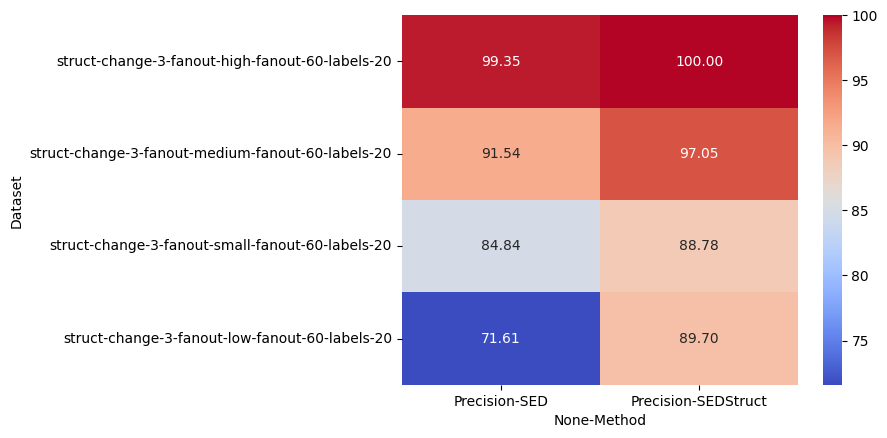

In [3]:
all_sed_candidates = pd.DataFrame()
all_sedstruct_candidates = pd.DataFrame()
for ds in datasets:
    sed_candidates = pd.read_csv(join(BASEPATH, f'{ds}/Sed_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sedstruct_candidates = pd.read_csv(join(BASEPATH, f'{ds}/SEDStruct_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sed_candidates.insert(0, 'Dataset', ds)
    sedstruct_candidates.insert(0, 'Dataset', ds)
    all_sed_candidates = pd.concat([all_sed_candidates, sed_candidates])
    all_sedstruct_candidates = pd.concat([all_sedstruct_candidates, sedstruct_candidates])
    
all_vdf = pd.DataFrame()
for ds in datasets:
    vdf = pd.read_csv(join(BASEPATH, f'{ds}/verified-all.csv'), engine="python", skipfooter=1)
    vdf.insert(0, 'Dataset', ds)
    all_vdf = pd.concat([all_vdf, vdf])
    
sed_joined = all_sed_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')
sedstruct_joined = all_sedstruct_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')

# Calculate verification times for each dataset separately
for dataset in datasets:
    sed_dataset_time = sed_joined[sed_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
    sedstruct_dataset_time = sedstruct_joined[sedstruct_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
    
    # Update the qdf dataframe for each dataset
    qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SED'), 'VerificationTime'] = sed_dataset_time
    qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SEDStruct'), 'VerificationTime'] = sedstruct_dataset_time
    
# Get SED precision
sed_precision = all_sed_candidates.groupby('Dataset').size().reset_index(name='SED_Total')
sed_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SED_Passed')
sed_precision = sed_precision.merge(sed_passed, on='Dataset', how='left').fillna(0)
sed_precision['Method'] = 'SED'
sed_precision['Precision'] = (sed_precision['SED_Passed'] / sed_precision['SED_Total']) * 100

#  Get SEDStruct precision
sedstruct_precision = all_sedstruct_candidates.groupby('Dataset').size().reset_index(name='SEDStruct_Total')
sedstruct_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SEDStruct_Passed')
sedstruct_precision = sedstruct_precision.merge(sedstruct_passed, on='Dataset', how='left').fillna(0)
sedstruct_precision['Method'] = 'SEDStruct'
sedstruct_precision['Precision'] = (sedstruct_precision['SEDStruct_Passed'] / sedstruct_precision['SEDStruct_Total']) * 100

# Combine results
precision_df = pd.concat([
    sed_precision[['Dataset', 'Method', 'SED_Total', 'SED_Passed', 'Precision']].rename(columns={'SED_Total': 'Total', 'SED_Passed': 'Passed'}),
    sedstruct_precision[['Dataset', 'Method', 'SEDStruct_Total', 'SEDStruct_Passed', 'Precision']].rename(columns={'SEDStruct_Total': 'Total', 'SEDStruct_Passed': 'Passed'})
])

precision_df

pdf = precision_df.pivot(index=['Dataset'], columns=['Method'], values=['Precision'])
pdf = pdf.reindex(datasets)
pdf

sns.heatmap(pdf, annot=True, fmt='.2f', cmap='coolwarm')

In [4]:
all_df = pd.DataFrame()
for ds in datasets:
  ldf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'tree_leafs.csv'), header=None)
  sdf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'tree_sizes.csv'), header=None)
  ddf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'avg_degrees.csv'), header=None)
  nddf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'degrees.csv'), header=None)
  combined_df = pd.concat([ldf, sdf, ddf, nddf], axis=1)
  combined_df.columns = ['leaf_count', 'tree_size', 'avg_degree', 'node_degree']
  combined_df['Dataset'] = ds
  
  all_df = pd.concat([all_df, combined_df], ignore_index=True)
  
all_df['leaf_percentage'] = (all_df['leaf_count'] / all_df['tree_size']) * 100
all_df
agg = all_df.groupby('Dataset').agg({'leaf_count': ['mean', 'sum', 'median', 'std'], 'tree_size': ['mean', 'sum', 'median', 'std'], 'leaf_percentage': ['mean', 'median', 'std']})

In [5]:
all_df

,leaf_count,tree_size,avg_degree,node_degree,Dataset,leaf_percentage
0,45.0,62.0,3.588235,38,struct-change-3-fanout-high-fanout-60-labels-20,72.580645
1,44.0,62.0,3.388889,1,struct-change-3-fanout-high-fanout-60-labels-20,70.967742
2,43.0,62.0,3.210526,1,struct-change-3-fanout-high-fanout-60-labels-20,69.354839
3,45.0,62.0,3.588235,3,struct-change-3-fanout-high-fanout-60-labels-20,72.580645
4,45.0,62.0,3.588235,1,struct-change-3-fanout-high-fanout-60-labels-20,72.580645
...,...,...,...,...,...,...
542327,NaN,NaN,NaN,1,struct-change-3-fanout-low-fanout-60-labels-20,NaN
542328,NaN,NaN,NaN,2,struct-change-3-fanout-low-fanout-60-labels-20,NaN
542329,NaN,NaN,NaN,2,struct-change-3-fanout-low-fanout-60-labels-20,NaN
542330,NaN,NaN,NaN,1,struct-change-3-fanout-low-fanout-60-labels-20,NaN


/tmp/ipykernel_4437/3958659649.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bx = sns.boxplot(data=all_df.dropna(subset=['tree_size']), x='Dataset', y='avg_degree', palette='Set3')


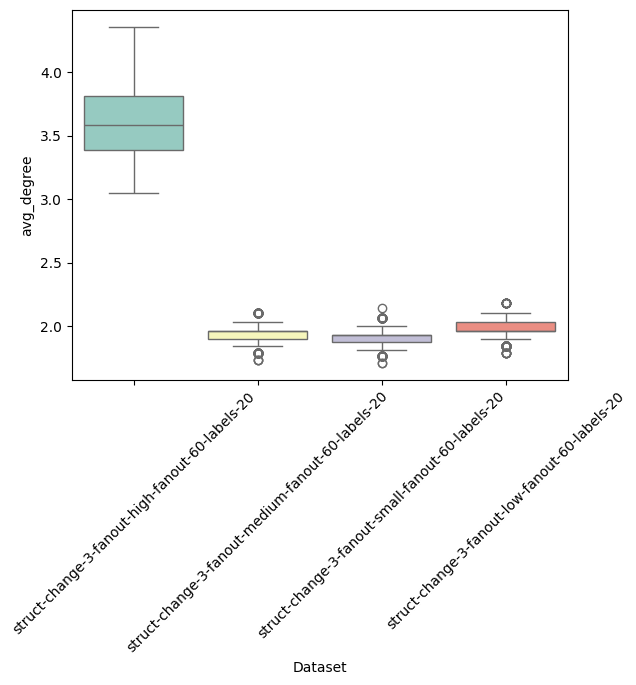

In [6]:
bx = sns.boxplot(data=all_df.dropna(subset=['tree_size']), x='Dataset', y='avg_degree', palette='Set3')
bx.tick_params(axis="x", rotation=45)

<Axes: xlabel='avg_degree', ylabel='Density'>

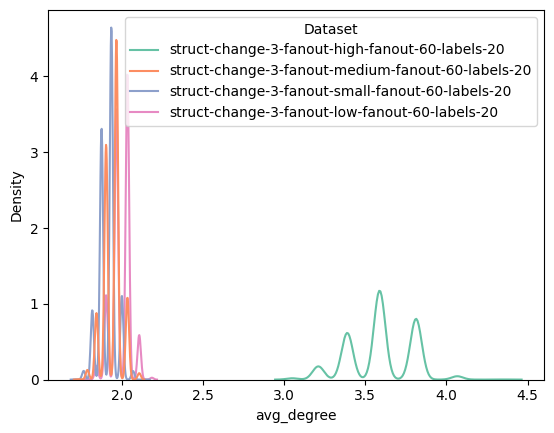

In [7]:
sns.kdeplot(data=all_df, x='avg_degree', hue='Dataset', palette='Set2')

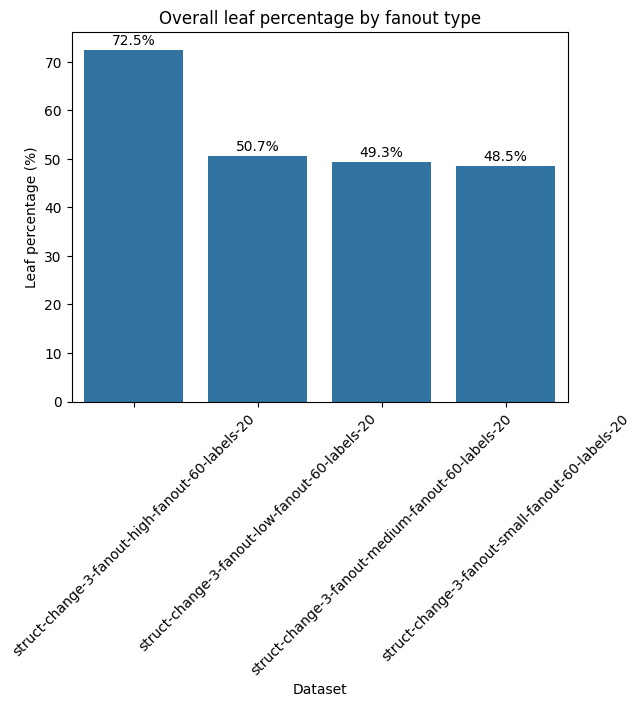

In [8]:
agg['leaf_percentage_col'] = (agg['leaf_count']['sum'] / agg['tree_size']['sum']) * 100
ax = sns.barplot(data=agg, x='Dataset', y='leaf_percentage_col')

# Annotate bars with actual values
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')

plt.ylabel('Leaf percentage (%)')
plt.title('Overall leaf percentage by fanout type')
ax.tick_params(axis='x', rotation=45)

In [93]:
dataset_trees = dict()

for ds in datasets:
    tree_path = join(BASEPATH, ds, 'query.csv')
    with open(tree_path, 'r') as f:
        tree_data = f.read()
        # split by lines
        lines = tree_data.splitlines()
        # count number of nodes
        dataset_trees[ds] = [l.split(';')[1] for l in lines]
        

In [94]:
class TreeNode:
    """Basic tree node class."""

    def __init__(self, label, index: int, size: int = 0, parent: "TreeNode" = None):
        self.label = label
        self.children: list[TreeNode] = []
        self.index = index
        self.size = size
        self.parent = parent

    def add_child(self, child: "TreeNode"):
        self.children.append(child)

    def get_size(self) -> int:
        _s = len(self.children)
        for c in self.children:
            _s += c.get_size()
        return _s

    # get all nodes of the tree
    def get_all_nodes(self) -> list["TreeNode"]:
        nodes = [self]
        for c in self.children:
            nodes.extend(c.get_all_nodes())
        return nodes

    def __repr__(self, level=0):
        # ret = "\t" * level + repr(self.label) + "\n"
        ret = r"{" + str(self.label)
        for child in self.children:
            ret += child.__repr__(level + 1)
        return ret + r"}"

    def __str__(self):
        return self.__repr__()
      
    @staticmethod
    def parse_tree(s: str) -> "TreeNode":
        """Parse a tree from a bracket notation string."""
        stack = []
        current_node = None
        index = 0

        i = 0
        while i < len(s):
            char = s[i]
            if char == "{":
                # Start a new node
                if current_node is not None:
                    stack.append(current_node)
                
                # Extract label after the opening bracket
                i += 1
                label_start = i
                while i < len(s) and s[i] not in "{}":
                    i += 1
                label = s[label_start:i]
                
                index += 1
                current_node = TreeNode(label=label, index=index)
            elif char == "}":
                # End the current node
                if stack:
                    parent_node = stack.pop()
                    parent_node.add_child(current_node)
                    current_node.parent = parent_node
                    current_node = parent_node
                i += 1
            else:
                # This shouldn't happen with proper bracket notation
                i += 1

        return current_node  # Root node

In [95]:
from concurrent.futures import ProcessPoolExecutor

dataset_tree_nodes = dict()
for ds in datasets:
    tree_lines = dataset_trees[ds]
    nodes = []
    with ProcessPoolExecutor() as executor:
        for parsed_tree in executor.map(TreeNode.parse_tree, tree_lines):
            nodes.append(parsed_tree)
    dataset_tree_nodes[ds] = nodes
    


In [96]:
# for each tree get some interesting statistics
def extract_tree_statistics(tree: TreeNode) -> dict:
  """Extract various statistics from a TreeNode tree."""
  
  def get_height(node: TreeNode) -> int:
    """Get the height of the tree."""
    if not node.children:
      return 0
    return 1 + max(get_height(child) for child in node.children)
  
  def get_leaf_count(node: TreeNode) -> int:
    """Count the number of leaf nodes."""
    if not node.children:
      return 1
    return sum(get_leaf_count(child) for child in node.children)
  
  def get_node_count(node: TreeNode) -> int:
    """Count the total number of nodes."""
    return 1 + sum(get_node_count(child) for child in node.children)
  
  def get_degrees(node: TreeNode) -> list:
    """Get the degree (number of children) of each node."""
    degrees = [len(node.children)]
    for child in node.children:
      degrees.extend(get_degrees(child))
    return degrees
  
  def get_depth_distribution(node: TreeNode, depth: int = 0) -> dict:
    """Get the distribution of nodes at each depth level."""
    distribution = {depth: 1}
    for child in node.children:
      child_dist = get_depth_distribution(child, depth + 1)
      for d, count in child_dist.items():
        distribution[d] = distribution.get(d, 0) + count
    return distribution
  
  # Calculate all statistics
  height = get_height(tree)
  leaf_count = get_leaf_count(tree)
  node_count = get_node_count(tree)
  degrees = get_degrees(tree)
  depth_dist = get_depth_distribution(tree)
  
  # Calculate derived statistics
  avg_degree = sum(degrees) / len(degrees) if degrees else 0
  max_degree = max(degrees) if degrees else 0
  min_degree = min(degrees) if degrees else 0
  branching_factor = sum(d for d in degrees if d > 0) / sum(1 for d in degrees if d > 0) if any(d > 0 for d in degrees) else 0
  leaf_ratio = leaf_count / node_count if node_count > 0 else 0
  
  return {
    'internal_degrees': [d for d in degrees if d > 0],
    'height': height,
    'node_count': node_count,
    'leaf_count': leaf_count,
    'leaf_ratio': leaf_ratio,
    'avg_degree': avg_degree,
    'max_degree': max_degree,
    'min_degree': min_degree,
    'med_degree': np.median(degrees) if degrees else 0,
    'branching_factor': branching_factor,
    'depth_distribution': depth_dist,
    'width': max(depth_dist.values()) if depth_dist else 0  # Maximum nodes at any level
  }

# Test the function with first tree from first dataset
sample_tree = dataset_tree_nodes[datasets[0]][0]
sample_stats = extract_tree_statistics(sample_tree)
print("Sample tree statistics:")
for key, value in sample_stats.items():
  if key != 'depth_distribution':
    print(f"{key}: {value}")


Sample tree statistics:
internal_degrees: [39, 1, 1, 3, 1, 1, 1, 2, 2, 2, 1, 3, 1, 1, 1, 1]
height: 3
node_count: 62
leaf_count: 46
leaf_ratio: 0.7419354838709677
avg_degree: 0.9838709677419355
max_degree: 39
min_degree: 0
med_degree: 0.0
branching_factor: 3.8125
width: 39


In [103]:
# Create a comprehensive dataframe with all tree statistics
all_tree_stats = pd.DataFrame()

another_stats = pd.DataFrame()

for ds in datasets:
  trees = dataset_tree_nodes[ds]
  dataset_stats = []
  degree_stats = []
  
  for i, tree in enumerate(trees):
    stats = extract_tree_statistics(tree)
    # Add dataset and tree index information
    stats['Dataset'] = ds
    stats['tree_index'] = i
    # Remove depth_distribution as it's a dict and not suitable for dataframe
    stats.pop('depth_distribution', None)

    degree_stats.extend({ 'Dataset': ds, 'tree_index': i, 'degree': deg } for deg in stats['internal_degrees'])
    stats.pop('internal_degrees', None)
    dataset_stats.append(stats)
  
  # Convert to dataframe and concatenate
  dataset_df = pd.DataFrame(dataset_stats)
  dataset_degree_df = pd.DataFrame(degree_stats)
  all_tree_stats = pd.concat([all_tree_stats, dataset_df], ignore_index=True)
  another_stats  = pd.concat([another_stats, dataset_degree_df], ignore_index=True)
# Display the resulting dataframe
all_tree_stats.head()
another_stats.head()

,Dataset,tree_index,degree
0,struct-change-3-fanout-high-fanout-60-labels-20,0,39
1,struct-change-3-fanout-high-fanout-60-labels-20,0,1
2,struct-change-3-fanout-high-fanout-60-labels-20,0,1
3,struct-change-3-fanout-high-fanout-60-labels-20,0,3
4,struct-change-3-fanout-high-fanout-60-labels-20,0,1


In [104]:
# create a summary statistics dataframe
summary_stats = []
for ds in datasets:
    ds_data = all_tree_stats[all_tree_stats['Dataset'] == ds]
    summary = {
        'Dataset': ds,
        'mean_leaf_count': ds_data['leaf_count'].mean(),
        'median_tree_size': ds_data['node_count'].median(),
        'std_avg_degree': ds_data['avg_degree'].std(),
        'mean_fanout': ds_data['branching_factor'].std(),
        'median_fanout': ds_data['branching_factor'].std(),
    }
    summary_stats.append(summary)

summary_df = pd.DataFrame(summary_stats)
summary_df 

,Dataset,mean_leaf_count,median_tree_size,std_avg_degree,mean_fanout,median_fanout
0,struct-change-3-fanout-high-fanout-60-labels-20,46.000000,62.0,3.347281e-16,0.000000,0.000000
1,struct-change-3-fanout-medium-fanout-60-labels-20,29.990099,60.0,1.115760e-16,0.006313,0.006313
2,struct-change-3-fanout-small-fanout-60-labels-20,29.950000,61.0,1.115816e-16,0.013249,0.013249
3,struct-change-3-fanout-low-fanout-60-labels-20,30.990099,60.0,1.115760e-16,0.006748,0.006748


In [105]:
# create a new dataframe, rename the dataset by extracting 'low-fanout', 'small-fanout', 'medium-fanout', 'high-fanout' from the dataset name
all_df = all_tree_stats.copy()
all_df['Dataset'] = all_df['Dataset'].apply(lambda x: x.split('-')[4] + '-' + x.split('-')[5])

In [106]:
all_df

,height,node_count,leaf_count,leaf_ratio,avg_degree,max_degree,min_degree,med_degree,branching_factor,width,Dataset,tree_index
0,3,62,46,0.741935,0.983871,39,0,0.0,3.812500,39,high-fanout,0
1,3,62,46,0.741935,0.983871,39,0,0.0,3.812500,39,high-fanout,1
2,3,62,46,0.741935,0.983871,39,0,0.0,3.812500,39,high-fanout,2
3,3,62,46,0.741935,0.983871,39,0,0.0,3.812500,39,high-fanout,3
4,3,62,46,0.741935,0.983871,39,0,0.0,3.812500,39,high-fanout,4
...,...,...,...,...,...,...,...,...,...,...,...,...
398,8,60,31,0.516667,0.983333,11,0,0.0,2.034483,14,low-fanout,96
399,8,60,31,0.516667,0.983333,11,0,0.0,2.034483,14,low-fanout,97
400,8,60,31,0.516667,0.983333,11,0,0.0,2.034483,14,low-fanout,98
401,8,60,31,0.516667,0.983333,11,0,0.0,2.034483,14,low-fanout,99


/tmp/ipykernel_4437/2941935491.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.displot(all_df, x='avg_degree', y="branching_factor", kind="kde", hue='Dataset', rug=True)


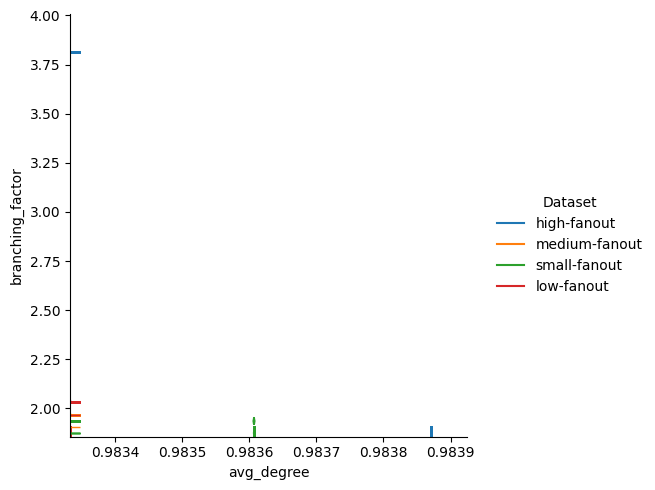

In [138]:
sns.displot(all_df, x='avg_degree', y="branching_factor", kind="kde", hue='Dataset', rug=True)

Text(0.5, 1.0, 'Fanout by Dataset')

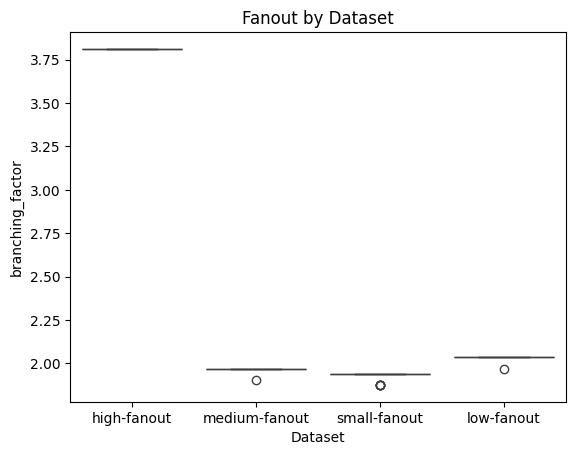

In [108]:
sns.boxplot(data=all_df, x='Dataset', y='branching_factor')
plt.title('Fanout by Dataset')

Text(0.5, 1.0, 'Width by Dataset')

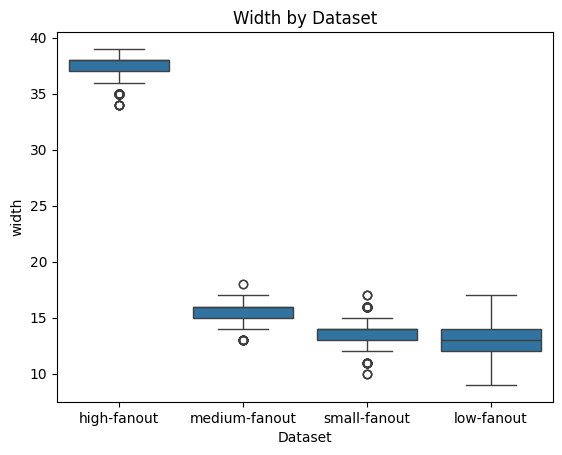

In [60]:
sns.boxplot(data=all_df, x='Dataset', y='width')
plt.title('Width by Dataset')

Text(0.5, 1.0, 'Height by Dataset')

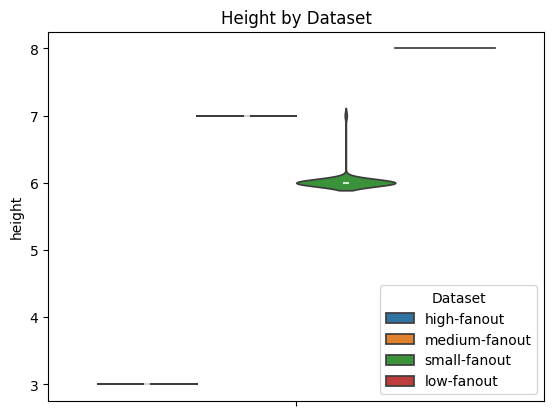

In [109]:
sns.violinplot(data=all_df, hue='Dataset', y='height')
plt.title('Height by Dataset')

In [110]:
all_df['width_height_ratio'] = all_df['width'] / all_df['height']

Text(0.5, 1.0, 'Width to Height Ratio by Dataset')

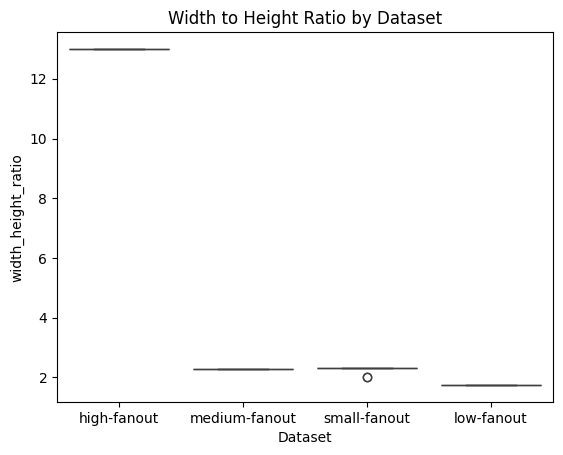

In [111]:
sns.boxplot(data=all_df, x='Dataset', y='width_height_ratio')
plt.title('Width to Height Ratio by Dataset')


Text(0.5, 1.0, 'Leaf nodes ratio per tree distribution')

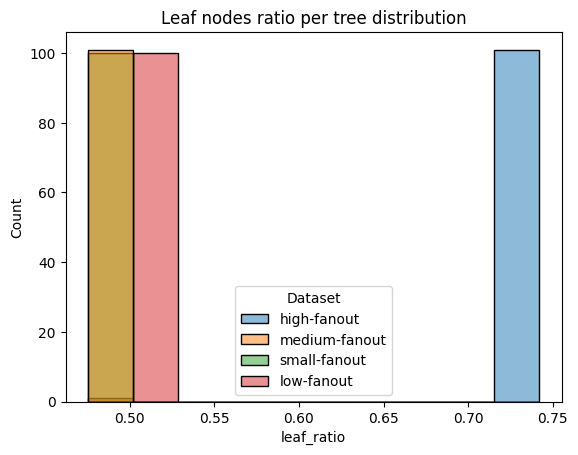

In [112]:
sns.histplot(all_df, x='leaf_ratio', hue='Dataset')
plt.title('Leaf nodes ratio per tree distribution')


Text(0.5, 1.0, 'Max node degree per tree distribution')

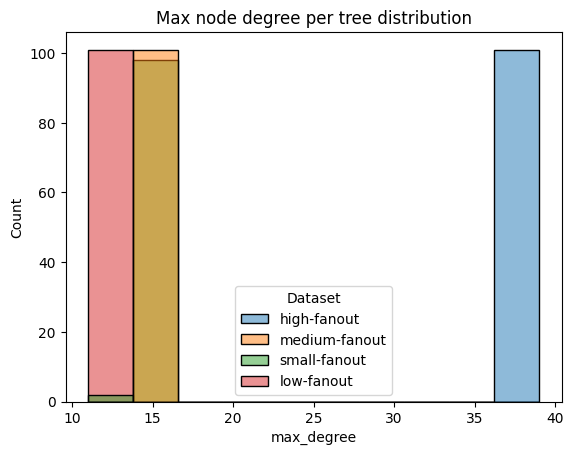

In [113]:
sns.histplot(all_df, x='max_degree', hue='Dataset')
plt.title('Max node degree per tree distribution')


Text(0.5, 1.0, 'Median node degree per tree distribution')

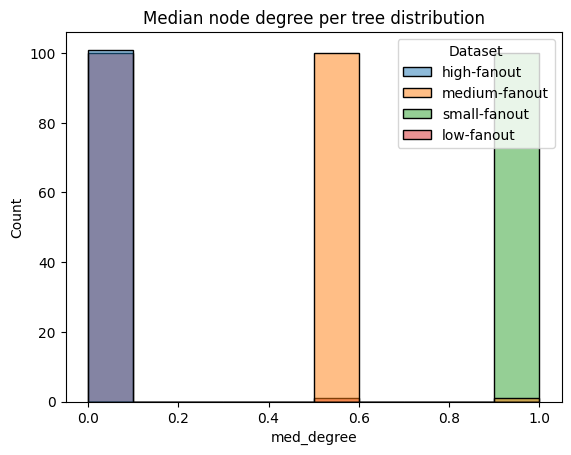

In [116]:
sns.histplot(all_df, x='med_degree', hue='Dataset')
plt.title('Median node degree per tree distribution')


<Axes: xlabel='Dataset', ylabel='degree'>

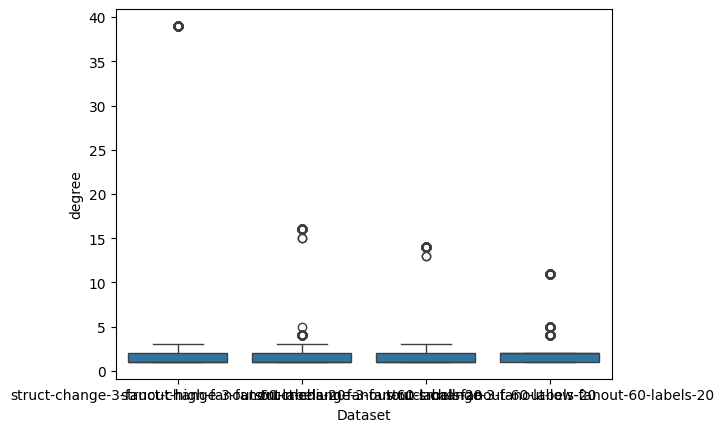

In [117]:
sns.boxplot(data=another_stats, x='Dataset', y='degree')